# Utqiagvik **T2m** Analysis
- Annual mean temperature timeseries in Alaskan region
- Notebook by Alice DuVivier (NCAR)
- January 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import geopandas as gpd
from metpy.calc import wind_speed
from metpy.calc import wind_direction
from scipy.stats import ttest_ind

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Load Regional Temperature Data

### Load CESM1-LE Data

In [2]:
# Select variable of interest and locate the files
varname = 'TREFHT'
path = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/' + varname

In [3]:
# list all ensemble numbers
ens_mems = ['001', '002', '003', '004', '005',
            '006', '007', '008', '009', '010',
            '011', '012', '013', '014', '015',
            '016', '017', '018', '019', '020',
            '021', '022', '023', '024', '025',
            '026', '027', '028', '029', '030',
            '031', '032', '033', '034', '035']

In [4]:
%%time

print('loading historical data')
ds_hist = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e11.B20TRC5CNBDRD.f09_g16.' + m

    files = sorted(glob(f'{path}/{case}.cam.h0.{varname}.??????-??????.nc'))       
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_hist = xr.concat([ds_hist,ds_tmp], dim='member_id')


loading historical data
CPU times: user 25.5 s, sys: 3.02 s, total: 28.5 s
Wall time: 36.3 s


In [5]:
%%time

print('loading future data')
ds_ssp = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e11.BRCP85C5CNBDRD.f09_g16.' + m

    files = sorted(glob(f'{path}/{case}.cam.h0.{varname}.??????-??????.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_ssp = xr.concat([ds_ssp,ds_tmp], dim='member_id')


loading future data
CPU times: user 28.5 s, sys: 3.23 s, total: 31.8 s
Wall time: 42.2 s


In [6]:
ds = xr.concat((ds_hist, ds_ssp),dim='time')

# keep just TREFHT variable
ds = ds.TREFHT

# calcluate annual mean temperatures
annual_mean_ds = ds.groupby('time.year').mean('time')

In [7]:
# keep just member_id 1-35 because for whatever reason 0 is missing data
annual_mean_ds = annual_mean_ds.sel(member_id=slice(1,36))

In [8]:
# Calculate statistics for just two years - 1979 and 2024

# grab just each year's data and all ensemble members
ds_1979 = annual_mean_ds.sel(year=1979)
ds_2024 = annual_mean_ds.sel(year=2024)

# calculate ensemble mean difference
diff = ds_2024.mean('member_id') - ds_1979.mean('member_id')

# calculate ttest of ensemble mean differences
t_statistic, p_value = ttest_ind(ds_1979.values, ds_2024.values, axis=0)

In [9]:
# save this dataset information
diff_cesm1le = diff
pval_cesm1le = p_value

### Load CESM2-LE Data

In [10]:
# Select variable of interest and locate the files
varname = 'TREFHT'
path = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/month_1/' + varname

In [11]:
# list all 50 cmip6 standard forcing ensemble numbers
ens_mems = ['1001.001', '1021.002', '1041.003', '1061.004', '1081.005', '1101.006', '1121.007', '1141.008', '1161.009', '1181.010',
            '1231.001', '1231.002', '1231.003', '1231.004', '1231.005', '1231.006', '1231.007', '1231.008', '1231.009', '1231.010',
            '1251.001', '1251.002', '1251.003', '1251.004', '1251.005', '1251.006', '1251.007', '1251.008', '1251.009', '1251.010',
            '1281.001', '1281.002', '1281.003', '1281.004', '1281.005', '1281.006', '1281.007', '1281.008', '1281.009', '1281.010',
            '1301.001', '1301.002', '1301.003', '1301.004', '1301.005', '1301.006', '1301.007', '1301.008', '1301.009', '1301.010']

In [12]:
%%time

print('loading historical data')
ds_hist = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e21.BHISTcmip6.f09_g17.LE2-' + m

    files = sorted(glob(f'{path}/{case}.cam.h0.{varname}.??????-??????.nc'))       
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_hist = xr.concat([ds_hist,ds_tmp], dim='member_id')


loading historical data
CPU times: user 1min 29s, sys: 7.73 s, total: 1min 37s
Wall time: 2min 25s


In [13]:
%%time

print('loading future data')
ds_ssp = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e21.BSSP370cmip6.f09_g17.LE2-' + m

    files = sorted(glob(f'{path}/{case}.cam.h0.{varname}.??????-??????.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_ssp = xr.concat([ds_ssp,ds_tmp], dim='member_id')


loading future data
CPU times: user 49.1 s, sys: 4.07 s, total: 53.1 s
Wall time: 1min 17s


In [14]:
ds = xr.concat((ds_hist, ds_ssp),dim='time')

# keep just TREFHT variable
ds = ds.TREFHT

# calcluate annual mean temperatures
annual_mean_ds = ds.groupby('time.year').mean('time')

In [15]:
# keep just member_id 1-50 because for whatever reason 0 is missing data
annual_mean_ds = annual_mean_ds.sel(member_id=slice(1,51))

In [16]:
# Calculate statistics for just two years - 1979 and 2024

# grab just each year's data and all ensemble members
ds_1979 = annual_mean_ds.sel(year=1979)
ds_2024 = annual_mean_ds.sel(year=2024)

# calculate ensemble mean difference
diff = ds_2024.mean('member_id') - ds_1979.mean('member_id')

# calculate ttest of ensemble mean differences
t_statistic, p_value = ttest_ind(ds_1979.values, ds_2024.values, axis=0)

In [17]:
# save this dataset information
diff_cesm2le = diff
pval_cesm2le = p_value

### Load CESM2-CMIP5 Data

In [18]:
# Select variable of interest and locate the files
varname = 'TREFHT'
path = '/glade/campaign/cesm/development/cross-wg/CESM2_CMIP5/'

In [19]:
# list all 15 ensemble numbers
ens_mems = ['001', '002', '003', '004', '005',
            '006', '007', '008', '009', '010',
            '011', '012', '013', '014', '015']

In [20]:
%%time

print('loading historical data')
ds_hist = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e21.BHIST.f09_g17.cesm2-cmip5.' + m
    path_full = path + case + '/atm/proc/tseries/month_1/'

    files = sorted(glob(f'{path_full}/{case}.cam.h0.{varname}.??????-??????.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_hist = xr.concat([ds_hist,ds_tmp], dim='member_id')


loading historical data
CPU times: user 11 s, sys: 601 ms, total: 11.6 s
Wall time: 16.5 s


In [21]:
%%time

print('loading future data')
ds_ssp = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'b.e21.BRCP85.f09_g17.cesm2-cmip5.' + m
    path_full = path + case + '/atm/proc/tseries/month_1/'

    files = sorted(glob(f'{path_full}/{case}.cam.h0.{varname}.??????-??????.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)

    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_ssp = xr.concat([ds_ssp,ds_tmp], dim='member_id')


loading future data
CPU times: user 11.3 s, sys: 585 ms, total: 11.9 s
Wall time: 15.6 s


In [22]:
ds = xr.concat((ds_hist, ds_ssp),dim='time')

# keep just TREFHT variable
ds = ds.TREFHT

# calcluate annual mean temperatures
annual_mean_ds = ds.groupby('time.year').mean('time')

In [23]:
# keep just member_id 1-16 because for whatever reason 0 is missing data
annual_mean_ds = annual_mean_ds.sel(member_id=slice(1,16))

In [24]:
# Calculate statistics for just two years - 1979 and 2024

# grab just each year's data and all ensemble members
ds_1979 = annual_mean_ds.sel(year=1979)
ds_2024 = annual_mean_ds.sel(year=2024)

# calculate ensemble mean difference
diff = ds_2024.mean('member_id') - ds_1979.mean('member_id')

# calculate ttest of ensemble mean differences
t_statistic, p_value = ttest_ind(ds_1979.values, ds_2024.values, axis=0)

In [25]:
# save this dataset information
diff_cesm2cmip5 = diff
pval_cesm2cmip5 = p_value

### Load MESACLIP Data
- two RCP options
- Has already been processed some to just Arctic and fixed time bound

In [26]:
# Select variable of interest and locate the files
varname = 'TREFHT'
path = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/mesaclip_all_arctic/monthly/TREFHT'

In [27]:
# list all 10 ensemble numbers
ens_mems = ['001', '002', '003', '004', '005',
            '006', '007', '008', '009', '010']

In [28]:
%%time

print('loading historical data')
ds_hist = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'MESACLIP_HIST_' + m

    files = sorted(glob(f'{path}/{case}_1920-2014_TREFHT_arctic_monthly.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)
    
    ds_hist = xr.concat([ds_hist,ds_tmp], dim='member_id')

# keep just member_id 1-11 because for whatever reason 0 is missing data
ds_hist = ds_hist.sel(member_id=slice(1,11))

loading historical data
CPU times: user 206 ms, sys: 19.8 ms, total: 225 ms
Wall time: 674 ms


In [29]:
%%time

print('loading future data - RCP6.0')
ds_rcp60 = xr.Dataset()

for m in ens_mems:
    #print(m)

    case = 'MESACLIP_RCP6.0_' + m

    files = sorted(glob(f'{path}/{case}_2015-2099_TREFHT_arctic_monthly.nc'))        
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)
    
    ds_rcp60 = xr.concat([ds_rcp60,ds_tmp], dim='member_id')

# keep just member_id 1-11 because for whatever reason 0 is missing data
ds_rcp60 = ds_rcp60.sel(member_id=slice(1,11))

loading future data - RCP6.0
CPU times: user 200 ms, sys: 23.9 ms, total: 224 ms
Wall time: 739 ms


In [30]:
# calcluate annual mean temperatures
annual_mean_hist = ds_hist.groupby('time.year').mean('time')
annual_mean_rcp60 = ds_rcp60.groupby('time.year').mean('time')

In [31]:
# Calculate statistics for just two years - 1979 and 2024

# grab just each year's data and all ensemble members
ds_1979 = annual_mean_hist.sel(year=1979).TREFHT
ds_2024_rcp60 = annual_mean_rcp60.sel(year=2024).TREFHT

In [32]:
### rcp6.0 stats
ds_2024 = ds_2024_rcp60

# calculate ensemble mean differences
diff = ds_2024.mean('member_id') - ds_1979.mean('member_id')

# calculate ttest of ensemble mean differences
t_statistic, p_value = ttest_ind(ds_1979.values, ds_2024.values, axis=0)

# save this dataset information
diff_mesaclip_rcp60 = diff
pval_mesaclip_rcp60 = p_value

## Load Local Temperature Data

### Load Barrow Observatory Data

In [33]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/NOAA_GML_BRW_MET/'

In [34]:
# years from 1974-2024
years_obs = np.arange(1974,2025,1)
nyrs = len(years_obs)
print(nyrs)

51


In [35]:
# preallocate some arrays
avg_array = np.zeros([nyrs])

# loop through each year to get the data and calculate annual average
for index, yy in enumerate(years_obs):
    file_in = 'brw_met_'+str(yy)+'.csv'
    #print(file_in)
    # load data with pandas
    df = pd.read_csv(dir_in+file_in)
    # read just the temperature values
    temp1 = df['T2m']
    # replace missing values (-999.9) with NaN
    temp2 = temp1.where(temp1> -999.9)
    # calculate annual mean and put this into an array
    avg_array[index] = temp2.mean()

# convert the numpy arrays to xarrays for easier plotting
data_obs = xr.DataArray(avg_array,dims=('years'))
data_obs['years'] = years_obs

In [36]:
# calculate an average temperature for 2000-2020
data_obs_sub = data_obs.where(data_obs.years >= 2000,drop=True)
data_obs_sub = data_obs_sub.where(data_obs_sub.years <= 2020, drop=True)
temp_avg_2000_2020 = data_obs_sub.mean()
temp_std_2000_2020 = data_obs_sub.std()
print(temp_avg_2000_2020)
print(temp_std_2000_2020)

# calculate an average temperature for 2014-2024
data_obs_sub = data_obs.where(data_obs.years >= 2014,drop=True)
temp_avg_2014_2024 = data_obs_sub.mean()
temp_std_2014_2024 = data_obs_sub.std()
print(temp_avg_2014_2024)
print(temp_std_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(1.2872061)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)
<xarray.DataArray ()> Size: 8B
array(1.55803959)


### Load CESM1-LE data

In [37]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [38]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [39]:
temp_cesm1le = ds.TREFHT

### Load CESM2-LE data

In [40]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [41]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [42]:
temp_cesm2le = ds.TREFHT

### Load CESM2-CMIP5 data

In [43]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [44]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [45]:
temp_cesm2cmip5 = ds.TREFHT

In [46]:
temp_cesm2cmip5.time

<xarray.DataArray 'time' (time: 66065)> Size: 529kB
array(['1920-01-01T00:00:00.000000000', '1920-01-02T00:00:00.000000000',
       '1920-01-03T00:00:00.000000000', ..., '2100-12-29T00:00:00.000000000',
       '2100-12-30T00:00:00.000000000', '2100-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 529kB 1920-01-01 1920-01-02 ... 2100-12-31
    lat      float64 8B ...
    lon      float64 8B ...

### Load MESACLIP data
- Two future scenarios so must load separately

In [47]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [48]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/1920', end='12/31/2005', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
temp_mesaclip_hist = ds.data_big_box

In [49]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/2006', end='12/31/2104', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

# keep this data
temp_mesaclip_rcp60 = ds.data_big_box

### Get the different numbers of ensembles
- Will need this later

In [50]:
# total ensemble members - will need this later
nens_cesm1le = len(temp_cesm1le.member_id)
print(nens_cesm1le)
nens_cesm2le = len(temp_cesm2le.member_id)
print(nens_cesm2le)
nens_cesm2cmip5 = len(temp_cesm2cmip5.member_id)
print(nens_cesm2cmip5)
nens_mesaclip = len(temp_mesaclip_hist.member_id)
print(nens_mesaclip)

35
50
15
10


## Process Annual Mean and ToE T2m data
- Timeseries: We need to first calculate the annual mean from daily data (or monthly data in the case of MESACLIP). Then from the annual mean temperatures for each ensemble member, we calculate mean and standard deviation. If we use daily data and average across everything then the variance is huge because of the annual cycle.
- Time of Emergence: Use baseline 51 years (1925-1975). ToE happens when ensemble mean drops below the +/-2 STD from baseline period

In [51]:
# years from 1920-2100
years_model = np.arange(1920,2101,1)
nyrs = len(years_model)
print(nyrs)

181


In [52]:
# CESM1-LE
data_model = temp_cesm1le

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm1le])
std_array = np.zeros([nyrs,nens_cesm1le])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### ToE - Get baseline means and standard deviation
# subset years
data_model_sub = model_avg.isel(years=slice(5,56))
# calculate mean and standard deviation over all years AND all ensemble members
avg_baseline = data_model_sub.mean(dim=['years','member_id'])
print(avg_baseline.values)
std_baseline = data_model_sub.std(dim=['years','member_id'])
print(std_baseline.values)

# Find TOE: When ensemble mean rises **above** baseline mean **plus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_ens_avg > toe_thresh_hi.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_ens_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
cesm1le_avg = model_ens_avg
cesm1le_std = model_ens_std
cesm1le_x_toe = x_toe
cesm1le_y_toe = y_toe
cesm1le_toe_thresh_hi = toe_thresh_hi.values
cesm1le_toe_thresh_low = toe_thresh_low.values

-14.73527724482432
1.7278933059058654
ToE exists, calculating index
2014


In [53]:
# CESM2-LE
data_model = temp_cesm2le

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm2le])
std_array = np.zeros([nyrs,nens_cesm2le])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### ToE - Get baseline means and standard deviation
# subset years
data_model_sub = model_avg.isel(years=slice(5,56))
# calculate mean and standard deviation over all years AND all ensemble members
avg_baseline = data_model_sub.mean(dim=['years','member_id'])
print(avg_baseline.values)
std_baseline = data_model_sub.std(dim=['years','member_id'])
print(std_baseline.values)

# Find TOE: When ensemble mean rises **above** baseline mean **plus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_ens_avg > toe_thresh_hi.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_ens_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
cesm2le_avg = model_ens_avg
cesm2le_std = model_ens_std
cesm2le_x_toe = x_toe
cesm2le_y_toe = y_toe
cesm2le_toe_thresh_hi = toe_thresh_hi.values
cesm2le_toe_thresh_low = toe_thresh_low.values

-9.82321434507183
1.5171293027513062
ToE exists, calculating index
2009


In [54]:
# CESM2-CMIP5
data_model = temp_cesm2cmip5

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm2cmip5])
std_array = np.zeros([nyrs,nens_cesm2cmip5])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### ToE - Get baseline means and standard deviation
# subset years
data_model_sub = model_avg.isel(years=slice(5,56))
# calculate mean and standard deviation over all years AND all ensemble members
avg_baseline = data_model_sub.mean(dim=['years','member_id'])
print(avg_baseline.values)
std_baseline = data_model_sub.std(dim=['years','member_id'])
print(std_baseline.values)

# Find TOE: When ensemble mean rises **above** baseline mean **plus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_ens_avg > toe_thresh_hi.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_ens_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
cesm2cmip5_avg = model_ens_avg
cesm2cmip5_std = model_ens_std
cesm2cmip5_x_toe = x_toe
cesm2cmip5_y_toe = y_toe
cesm2cmip5_toe_thresh_hi = toe_thresh_hi.values
cesm2cmip5_toe_thresh_low = toe_thresh_low.values

-10.540688907398897
1.4693874649317074
ToE exists, calculating index
2019


In [55]:
# MESACLIP - RCP6.0
data_model = xr.concat([temp_mesaclip_hist,temp_mesaclip_rcp60], dim='time')

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from monthly data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### ToE - Get baseline means and standard deviation
# subset years
data_model_sub = model_avg.isel(years=slice(5,56))
# calculate mean and standard deviation over all years AND all ensemble members
avg_baseline = data_model_sub.mean(dim=['years','member_id'])
print(avg_baseline.values)
std_baseline = data_model_sub.std(dim=['years','member_id'])
print(std_baseline.values)

# Find TOE: When ensemble mean rises **above** baseline mean **plus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_ens_avg > toe_thresh_hi.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_ens_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
mesaclip60_avg = model_ens_avg
mesaclip60_std = model_ens_std
mesaclip60_x_toe = x_toe
mesaclip60_y_toe = y_toe
mesaclip60_toe_thresh_hi = toe_thresh_hi.values
mesaclip60_toe_thresh_low = toe_thresh_low.values

-11.001612353759803
1.6002841510681804
ToE exists, calculating index
2012


## Plot timeseries and scatter plots

In [56]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_6/'

In [57]:
# calculate an average temperature for 2000-2020
print(temp_avg_2000_2020)

# calculate an average temperature for 2014-2024
print(temp_avg_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)


In [58]:
# set significance level (0.05 --> 95%)
sigval = 0.05

In [59]:
# set village location
name_village = 'Utqiagvik'
lat_village = 71.29
lon_village = 203.21

cc = 'black' #'dodgerblue'

In [60]:
# set some plotting info
#cmap_in = plt.cm.get_cmap('bwr')
#vmin_in = -6.0
#vmax_in = 6.0

cmap_in = plt.cm.get_cmap('YlOrRd')
vmin_in = 0.0
vmax_in = 8.0

In [61]:
# set latitude and longitudes
lats = diff_cesm1le.lat
lons = diff_cesm1le.lon

lats_mc = diff_mesaclip_rcp60.lat
lons_mc = diff_mesaclip_rcp60.lon

### All Models on one Plot

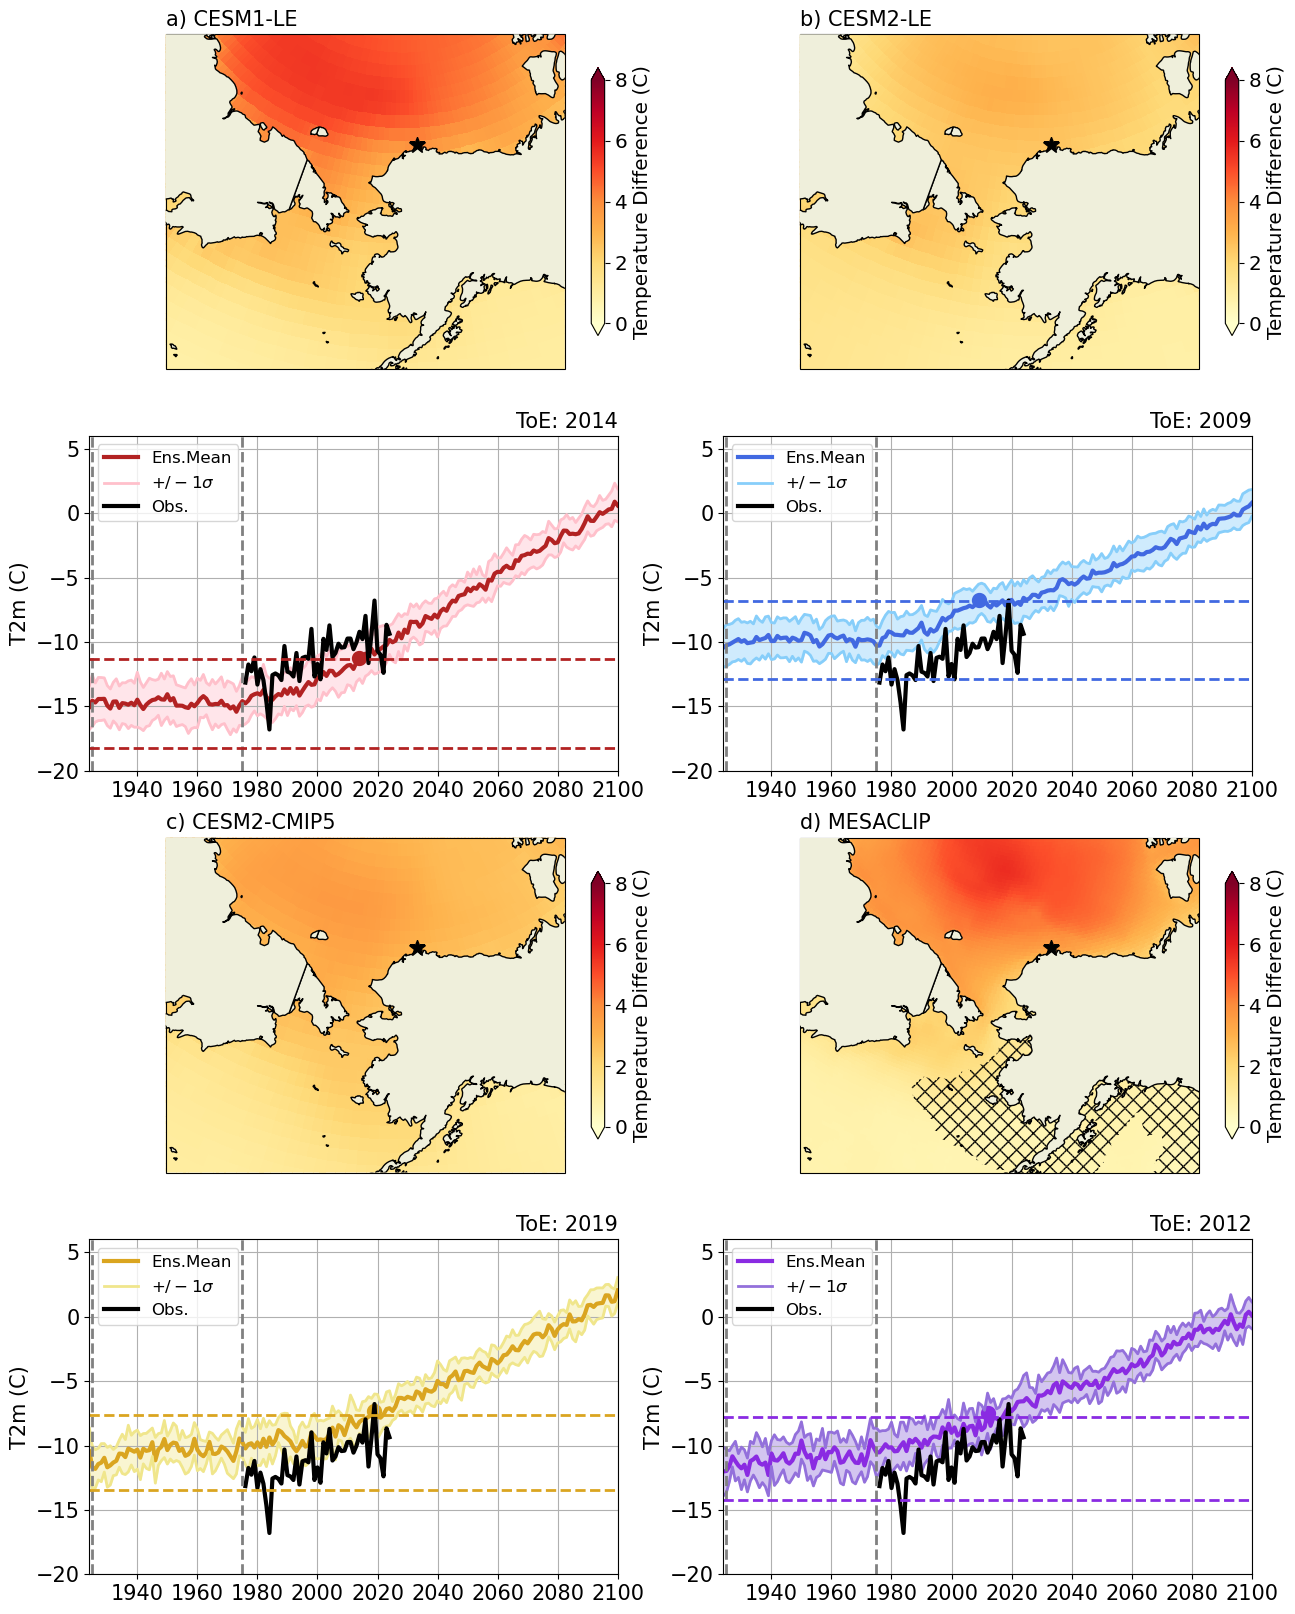

In [62]:
# create figure
fig = plt.figure(figsize=(15,20))
# now loop through months to create subpanels
fout = 'fig1_temperature_map_timeseries'

# Make subplot - note it's nrow x ncol x index (starting upper left)
### Plot 1 - first dataset map ###
# Set data
data = diff_cesm1le
pvalues = pval_cesm1le
# Make map
ax = fig.add_subplot(4,2,1, projection=ccrs.NorthPolarStereo(central_longitude=200.0))
ax.set_extent([170, 220, 78, 55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
this=ax.pcolormesh(lons,lats,data,
                   cmap=cmap_in,vmax=vmax_in,vmin=vmin_in,
                   transform=ccrs.PlateCarree())
cbar = ax.figure.colorbar(this,orientation='vertical',extend='both',fraction=0.05,pad=0.05,shrink=0.8)
cbar.ax.tick_params(labelsize='x-large')
cbar.ax.set_ylabel('Temperature Difference (C)',fontsize='x-large')
# Overlay significance
sig = ax.pcolor(lons,lats,data.where(pvalues > sigval),
                alpha=0,hatch='xx',
                transform=ccrs.PlateCarree()) 
# Add Utqiagvik location
ax.plot(lon_village, lat_village, marker="*", markersize=12,color=cc,zorder=100,transform=ccrs.PlateCarree())
# Add label
plt.title('a) CESM1-LE',loc='left',fontsize=15)

### Plot 2 - second dataset map ###
# Set data
data = diff_cesm2le
pvalues = pval_cesm2le
# Make map
ax = fig.add_subplot(4,2,2, projection=ccrs.NorthPolarStereo(central_longitude=200.0))
ax.set_extent([170, 220, 78, 55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
this=ax.pcolormesh(lons,lats,data,
                   cmap=cmap_in,vmax=vmax_in,vmin=vmin_in,
                   transform=ccrs.PlateCarree())
cbar = ax.figure.colorbar(this,orientation='vertical',extend='both',fraction=0.05,pad=0.05,shrink=0.8)
cbar.ax.tick_params(labelsize='x-large')
cbar.ax.set_ylabel('Temperature Difference (C)',fontsize='x-large')
# Overlay significance
sig = ax.pcolor(lons,lats,data.where(pvalues > sigval),
                alpha=0,hatch='xx',
                transform=ccrs.PlateCarree()) 
# Add Utqiagvik location
ax.plot(lon_village, lat_village, marker="*", markersize=12,color=cc,zorder=100,transform=ccrs.PlateCarree())
# Add label
plt.title('b) CESM2-LE',loc='left',fontsize=15)

### Plot 3 - first dataset timeseries ###
ax = fig.add_subplot(4,2,3)
# set data
c1 = 'firebrick'
c2 = 'pink'
data_avg = cesm1le_avg
data_std = cesm1le_std
toe_hi = cesm1le_toe_thresh_hi
toe_lo = cesm1le_toe_thresh_low
toe_x = cesm1le_x_toe
toe_y = cesm1le_y_toe
toe = str(toe_x)
## Model Data
ax.plot(years_model,data_avg,color=c1,label='Ens.Mean',linestyle='-',linewidth=3)
ax.plot(years_model,data_avg-data_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,data_avg+data_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, data_avg, data_avg+data_std, color=c2, alpha=0.4)
plt.fill_between(years_model, data_avg, data_avg-data_std, color=c2, alpha=0.4)
# Obs from Barrow Observatory
ax.plot(years_obs,data_obs,color="black",label='Obs.',linestyle='-',linewidth=3)        
## ToE values
plt.axvline(x=1925, color='grey', linestyle='--', linewidth=2)
plt.axvline(x=1975, color='grey', linestyle='--', linewidth=2)
plt.axhline(y=toe_hi, color=c1, linestyle='--', linewidth=2)
plt.axhline(y=toe_lo, color=c1, linestyle='--', linewidth=2)
plt.scatter(toe_x,toe_y, c=c1, marker="o",linewidth=5)
# modify labels and legend
#plt.title('d) CESM2-LE',loc='left',fontsize=15)
plt.title('ToE: '+toe,loc='right',fontsize=15)
#plt.xlabel('year',fontsize=20)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('T2m (C)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-20,6])
plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1)

### Plot 4 - second dataset timeseries ###
ax = fig.add_subplot(4,2,4)
# set data
c1 = 'royalblue'
c2 = 'lightskyblue'
data_avg = cesm2le_avg
data_std = cesm2le_std
toe_hi = cesm2le_toe_thresh_hi
toe_lo = cesm2le_toe_thresh_low
toe_x = cesm2le_x_toe
toe_y = cesm2le_y_toe
toe = str(toe_x)
## Model Data
ax.plot(years_model,data_avg,color=c1,label='Ens.Mean',linestyle='-',linewidth=3)
ax.plot(years_model,data_avg-data_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,data_avg+data_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, data_avg, data_avg+data_std, color=c2, alpha=0.4)
plt.fill_between(years_model, data_avg, data_avg-data_std, color=c2, alpha=0.4)
# Obs from Barrow Observatory
ax.plot(years_obs,data_obs,color="black",label='Obs.',linestyle='-',linewidth=3)        
## ToE values
plt.axvline(x=1925, color='grey', linestyle='--', linewidth=2)
plt.axvline(x=1975, color='grey', linestyle='--', linewidth=2)
plt.axhline(y=toe_hi, color=c1, linestyle='--', linewidth=2)
plt.axhline(y=toe_lo, color=c1, linestyle='--', linewidth=2)
plt.scatter(toe_x,toe_y, c=c1, marker="o",linewidth=5)
# modify labels and legend
#plt.title('e) CESM1-LE',loc='left',fontsize=15)
plt.title('ToE: '+toe,loc='right',fontsize=15)
#plt.xlabel('year',fontsize=20)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('T2m (C)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-20,6])
plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1)

### Plot 5 - third dataset map ###
# Set data
data = diff_cesm2cmip5
pvalues = pval_cesm2cmip5
# Make map
ax = fig.add_subplot(4,2,5, projection=ccrs.NorthPolarStereo(central_longitude=200.0))
ax.set_extent([170, 220, 78, 55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
this=ax.pcolormesh(lons,lats,data,
                   cmap=cmap_in,vmax=vmax_in,vmin=vmin_in,
                   transform=ccrs.PlateCarree())
cbar = ax.figure.colorbar(this,orientation='vertical',extend='both',fraction=0.05,pad=0.05,shrink=0.8)
cbar.ax.tick_params(labelsize='x-large')
cbar.ax.set_ylabel('Temperature Difference (C)',fontsize='x-large')
# Overlay significance
sig = ax.pcolor(lons,lats,data.where(pvalues > sigval),
                alpha=0,hatch='xx',
                transform=ccrs.PlateCarree()) 
# Add Utqiagvik location
ax.plot(lon_village, lat_village, marker="*", markersize=12,color=cc,zorder=100,transform=ccrs.PlateCarree())
# Add label
plt.title('c) CESM2-CMIP5',loc='left',fontsize=15)

### Plot 6 - fourth dataset map ###
# Set data
data = diff_mesaclip_rcp60
pvalues = pval_mesaclip_rcp60
# Make map
ax = fig.add_subplot(4,2,6, projection=ccrs.NorthPolarStereo(central_longitude=200.0))
ax.set_extent([170, 220, 78, 55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=50,edgecolor='k')
this=ax.pcolormesh(lons_mc,lats_mc,data,
                   cmap=cmap_in,vmax=vmax_in,vmin=vmin_in,
                   transform=ccrs.PlateCarree())
cbar = ax.figure.colorbar(this,orientation='vertical',extend='both',fraction=0.05,pad=0.05,shrink=0.8)
cbar.ax.tick_params(labelsize='x-large')
cbar.ax.set_ylabel('Temperature Difference (C)',fontsize='x-large')
# Overlay significance
sig = ax.pcolor(lons_mc,lats_mc,data.where(pvalues > sigval),
                alpha=0,hatch='xx',
                transform=ccrs.PlateCarree()) 
# Add Utqiagvik location
ax.plot(lon_village, lat_village, marker="*", markersize=12,color=cc,zorder=100,transform=ccrs.PlateCarree())
# Add label
plt.title('d) MESACLIP',loc='left',fontsize=15)

### Plot 7 - third dataset timeseries ###
ax = fig.add_subplot(4,2,7)
# set data
c1 = 'goldenrod'
c2 = 'khaki'
data_avg = cesm2cmip5_avg
data_std = cesm2cmip5_std
toe_hi = cesm2cmip5_toe_thresh_hi
toe_lo = cesm2cmip5_toe_thresh_low
toe_x = cesm2cmip5_x_toe
toe_y = cesm2cmip5_y_toe
toe = str(toe_x)
## Model Data
ax.plot(years_model,data_avg,color=c1,label='Ens.Mean',linestyle='-',linewidth=3)
ax.plot(years_model,data_avg-data_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,data_avg+data_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, data_avg, data_avg+data_std, color=c2, alpha=0.4)
plt.fill_between(years_model, data_avg, data_avg-data_std, color=c2, alpha=0.4)
# Obs from Barrow Observatory
ax.plot(years_obs,data_obs,color="black",label='Obs.',linestyle='-',linewidth=3)        
## ToE values
plt.axvline(x=1925, color='grey', linestyle='--', linewidth=2)
plt.axvline(x=1975, color='grey', linestyle='--', linewidth=2)
plt.axhline(y=toe_hi, color=c1, linestyle='--', linewidth=2)
plt.axhline(y=toe_lo, color=c1, linestyle='--', linewidth=2)
plt.scatter(toe_x,toe_y, c=c1, marker="o",linewidth=5)
# modify labels and legend
#plt.title('d) CESM2-LE',loc='left',fontsize=15)
plt.title('ToE: '+toe,loc='right',fontsize=15)
#plt.xlabel('year',fontsize=20)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('T2m (C)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-20,6])
plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1)

### Plot 8 - fourth dataset timeseries ###
ax = fig.add_subplot(4,2,8)
# set data
c1 = 'blueviolet'
c2 = 'mediumpurple'
data_avg = mesaclip60_avg
data_std = mesaclip60_std
toe_hi = mesaclip60_toe_thresh_hi
toe_lo = mesaclip60_toe_thresh_low
toe_x = mesaclip60_x_toe
toe_y = mesaclip60_y_toe
toe = str(toe_x)
## Model Data - HIST and RCP6.0
ax.plot(years_model,data_avg,color=c1,label='Ens.Mean',linestyle='-',linewidth=3)
ax.plot(years_model,data_avg-data_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,data_avg+data_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, data_avg, data_avg+data_std, color=c2, alpha=0.4)
plt.fill_between(years_model, data_avg, data_avg-data_std, color=c2, alpha=0.4)
# Obs from Barrow Observatory
ax.plot(years_obs,data_obs,color="black",label='Obs.',linestyle='-',linewidth=3)        
## ToE values
plt.axvline(x=1925, color='grey', linestyle='--', linewidth=2)
plt.axvline(x=1975, color='grey', linestyle='--', linewidth=2)
plt.axhline(y=toe_hi, color=c1, linestyle='--', linewidth=2)
plt.axhline(y=toe_lo, color=c1, linestyle='--', linewidth=2)
plt.scatter(toe_x,toe_y, c=c1, marker="o",linewidth=5)
# modify labels and legend
#plt.title('d) MESACLIP',loc='left',fontsize=15)
#plt.title('ToE: '+toe+'/2013',loc='right',fontsize=15)
plt.title('ToE: '+toe,loc='right',fontsize=15)
#plt.xlabel('year',fontsize=20)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('T2m (C)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-20,6])
plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1)

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)